<a href="https://colab.research.google.com/github/freida20git/bird-detection-tracking/blob/main/Algorithms_inference_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/birds_sky.mp4 - Frames: 437, Duration: 17.48 seconds

/content/oclusion_birds.mp4 - Frames: 350, Duration: 14.58 seconds

/content/similar_birds.mp4 - Frames: 304, Duration: 10.13 seconds

/content/birds_beach.mp4 - Frames: 252, Duration: 10.08 seconds

/content/desert_birds.mp4 - Frames: 1026, Duration: 42.75 seconds

/content/sunset_birds.mp4 - Frames: 874, Duration: 29.13 seconds

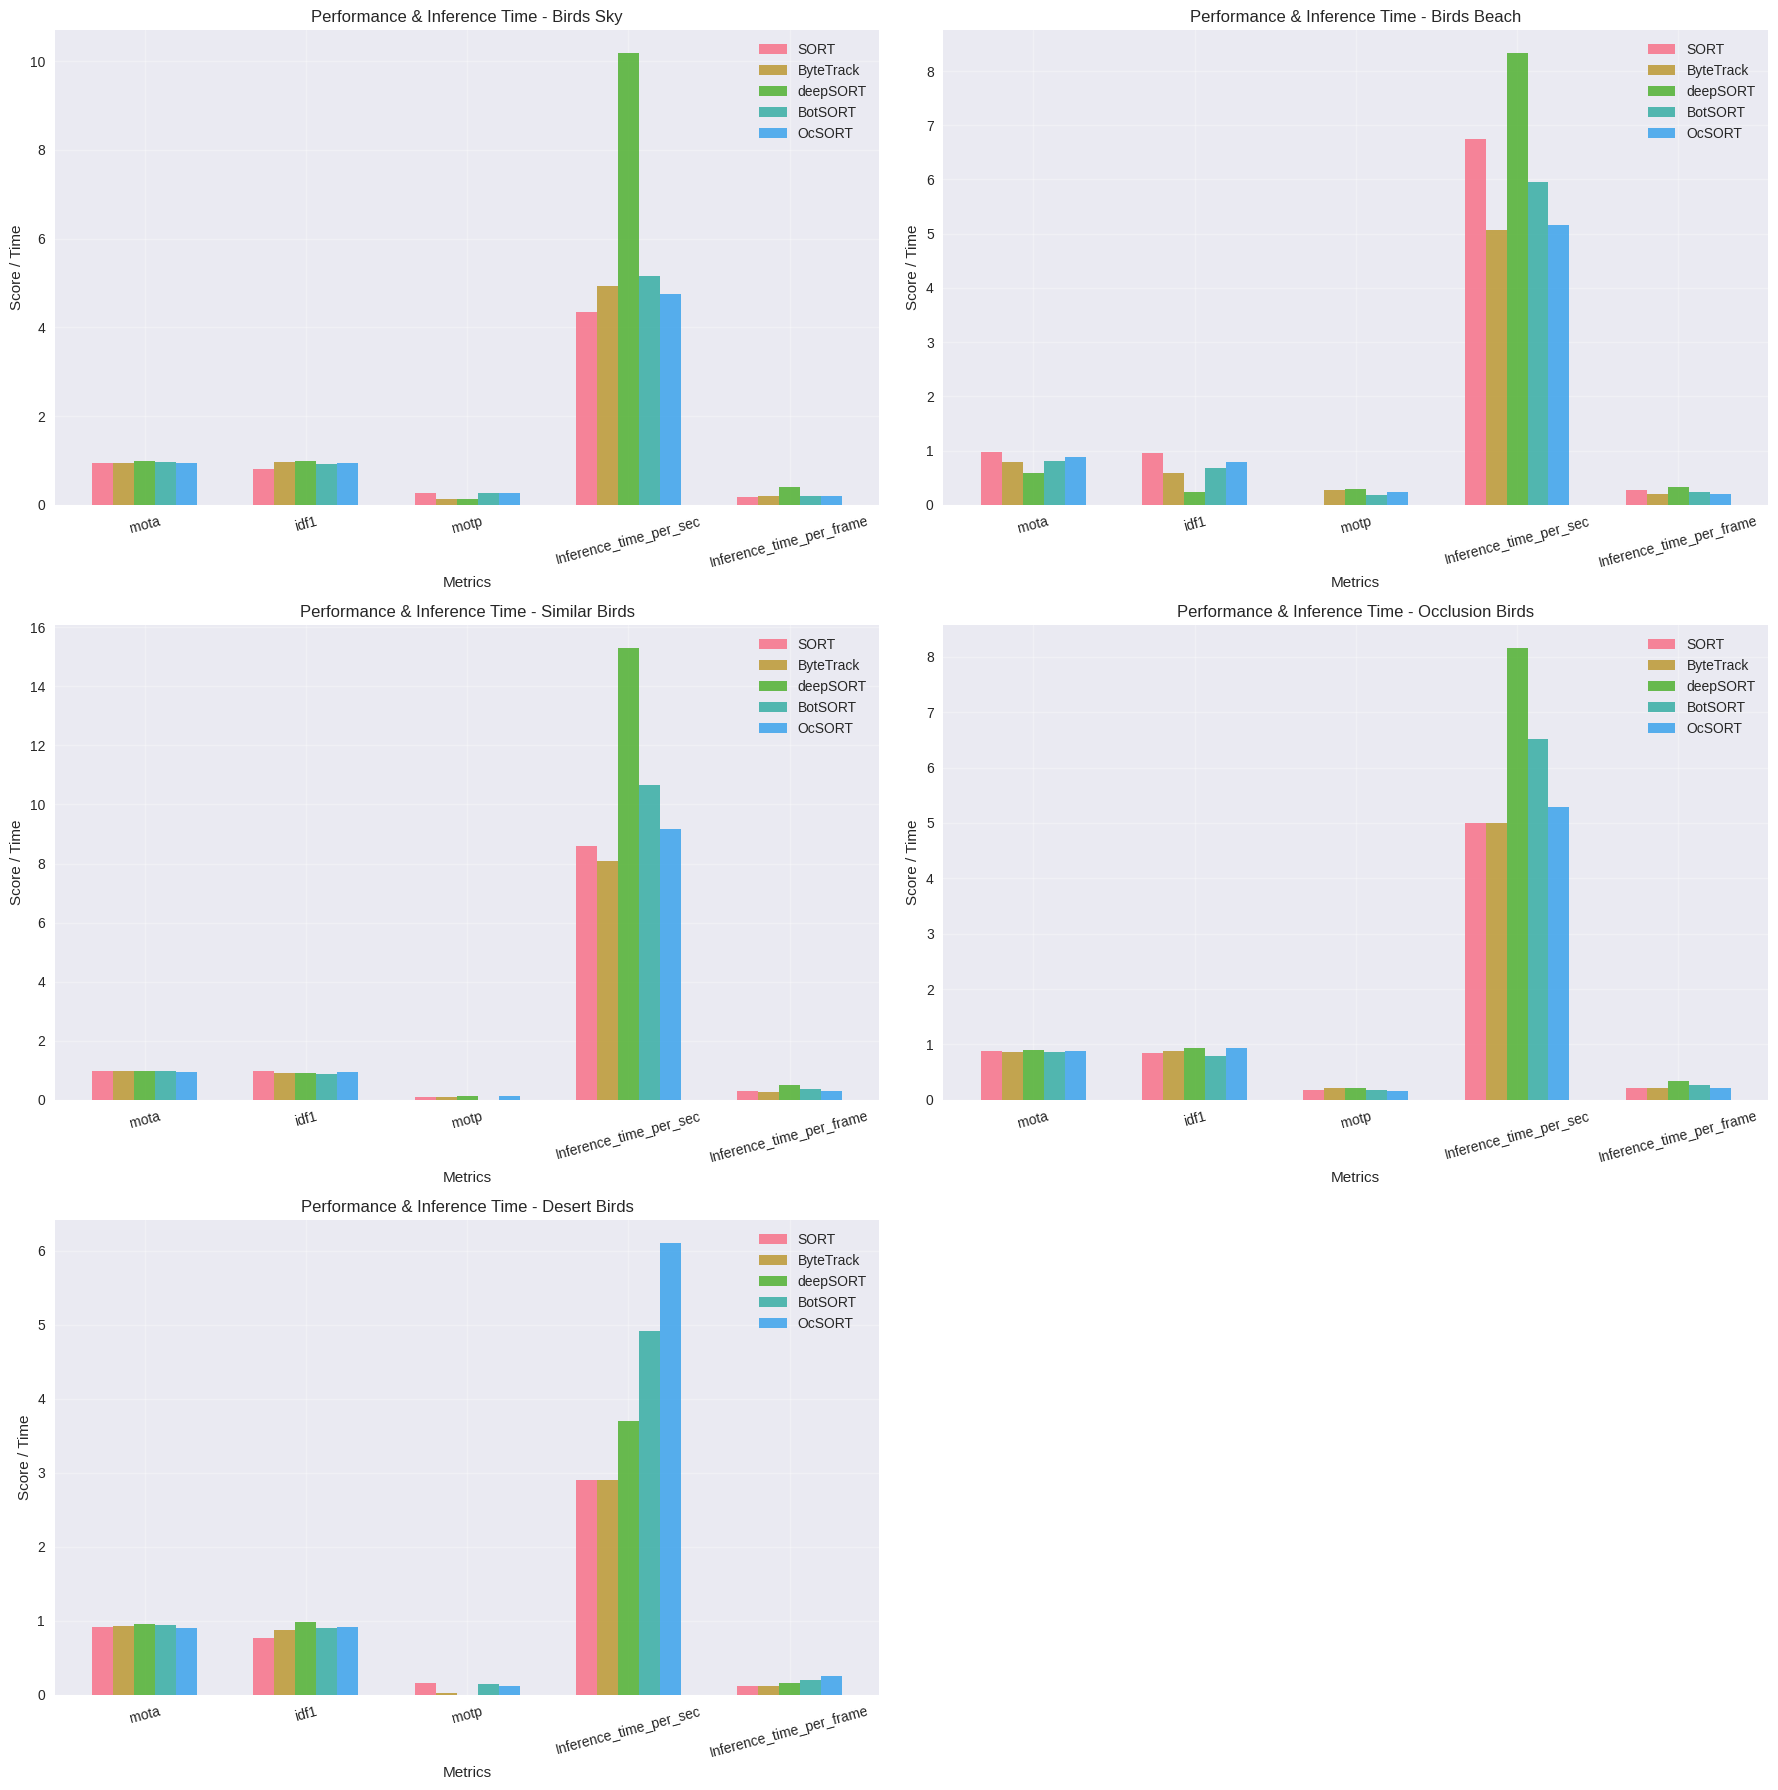

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data
sort_data = [
    ["SORT", "Birds flying in the sky preview", 76, 18, 0.888, 0.391, 0.27, 0.94, 0.8],
    ["SORT", "Birds Beach", 68, 12, np.nan, np.nan, 0.005, 0.978, 0.956],
    ["SORT", "Similar Birds", 87, 15, 0.969, 0.826, 0.084, 0.96, 0.97],
    ["SORT", "Oclusion birds",73 , 4, 0.914, 0.6, 0.18, 0.885, 0.84],
    ["SORT", "Desert_birds",124, 11, 0.928, 0.641,  0.153, 0.919, 0.765]
]
bytetrack_data = [
    ["ByteTrack", "Birds flying in the sky preview", 86, 8, 0.951, 0.681, 0.14, 0.94, 0.97],
    ["ByteTrack", "Birds Beach", 51, 35, 0.832, 0.404, 0.27, 0.79, 0.59],
    ["ByteTrack", "Similar Birds", 82, 12, 0.979, 0.745, 0.108, 0.964, 0.9],
    ["ByteTrack", "Oclusion birds", 73, 4, 0.912, 0.475, 0.22, 0.87, 0.88],
    ["ByteTrack", "Desert_birds",124, 8, 0.951, 0.918 ,0.03, 0.93,0.87]
]
deepsort_data = [
    ["deepSORT", "Birds flying in the sky preview", 178, 1, 0.97, 0.73, 0.13, 0.98, 0.98],
    ["deepSORT", "Birds Beach", 84, 126, 0.782, 0.345, 0.289, 0.586, 0.24],
    ["deepSORT", "Similar Birds", 155, 9, 0.979, 0.745, 0.137, 0.965, 0.899],
    ["deepSORT", "Oclusion birds", 119, 2, 0.912, 0.489, 0.22, 0.892, 0.93],
    ["deepSORT", "Desert_birds",158, 0.1, 0.974, 0.974, 0, 0.96, 0.98]
]
botsort_data = [
    ["BotSORT", "Birds flying in the sky preview", 90, 3, 0.884, 0.381, 0.27, 0.96, 0.92],
    ["BotSORT", "Birds beach", 60, 34, 0.898, 0.617, 0.173, 0.8, 0.67],
    ["BotSORT", "Similar Birds", 108, 16, np.nan, np.nan, 0.001, 0.97, 0.87],
    ["BotSORT", "Oclusion birds", 95, 3, 0.923, 0.625, 0.17, 0.87, 0.797],
    ["BotSORT", "Desert_birds",210, 3, 0.94, 0.662, 0.139, 0.94, 0.9]
]
ocsort_data = [
    ["OcSORT", "Birds flying in the sky preview", 83, 5, 0.85, 0.36, 0.27, 0.95, 0.95],
    ["OcSORT", "Oclusion birds", 77, 2, 0.89, 0.57, 0.16, 0.89, 0.93],
    ["OcSORT", "Birds Beach", 52, 4, np.nan, np.nan, 0.244, 0.88, 0.7814],
    ["OcSORT", "Similar Birds", 93, 6, np.nan, np.nan, 0.12, 0.95, 0.943],
    ["OcSORT", "Desert_birds", 261, 9, np.nan, np.nan, 0.121, 0.90,0.91]
]

video_lengths_sec = {
    "Birds Sky": 17.48,
    "Birds Beach": 10.08,
    "Similar Birds": 10.13,
    "Occlusion Birds": 14.58,
    "Desert Birds": 42.75
}
video_num_frames = {
    "Birds Sky": 437,
    "Birds Beach": 252,
    "Similar Birds": 304,
    "Occlusion Birds": 350,
    "Desert Birds": 1026
}

# Combine all data
all_data = sort_data + bytetrack_data + deepsort_data + botsort_data + ocsort_data
columns = ['Algorithm', 'Video', 'Inference_time_sec', 'num_switches', 'mAP50', 'mAP50-95', 'motp', 'mota', 'idf1']
df = pd.DataFrame(all_data, columns=columns)

# Fix names
df['Video'] = df['Video'].str.replace('Birds beach', 'Birds Beach', regex=False)
df['Video'] = df['Video'].str.replace('Birds flying in the sky preview', 'Birds Sky', regex=False)
df['Video'] = df['Video'].str.replace('Oclusion birds', 'Occlusion Birds', regex=False)
df['Video'] = df['Video'].str.replace('Desert_birds', 'Desert Birds', regex=False)


# Add derived metrics
df['Video_length_sec'] = df['Video'].map(video_lengths_sec)
df['Num_frames'] = df['Video'].map(video_num_frames)
df['Inference_time_per_sec'] = df['Inference_time_sec'] / df['Video_length_sec']
df['Inference_time_per_frame'] = df['Inference_time_sec'] / df['Num_frames']

# Metrics to show
metrics_to_plot = ['mota', 'idf1', 'motp', 'Inference_time_per_sec', 'Inference_time_per_frame']

# Plot
videos = df['Video'].unique()
n_videos = len(videos)
n_cols = 2
n_rows = math.ceil(n_videos / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, video in enumerate(videos):
    ax = axes[i]
    video_data = df[df['Video'] == video]
    x_pos = np.arange(len(metrics_to_plot))
    width = 0.13
    for j, algorithm in enumerate(df['Algorithm'].unique()):
        algo_data = video_data[video_data['Algorithm'] == algorithm]
        if not algo_data.empty:
            values = [algo_data[metric].iloc[0] if not pd.isna(algo_data[metric].iloc[0]) else 0
                      for metric in metrics_to_plot]
            ax.bar(x_pos + j*width, values, width, label=algorithm, alpha=0.85)
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score / Time')
    ax.set_title(f'Performance & Inference Time - {video}')
    ax.set_xticks(x_pos + width * 2)
    ax.set_xticklabels(metrics_to_plot, rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


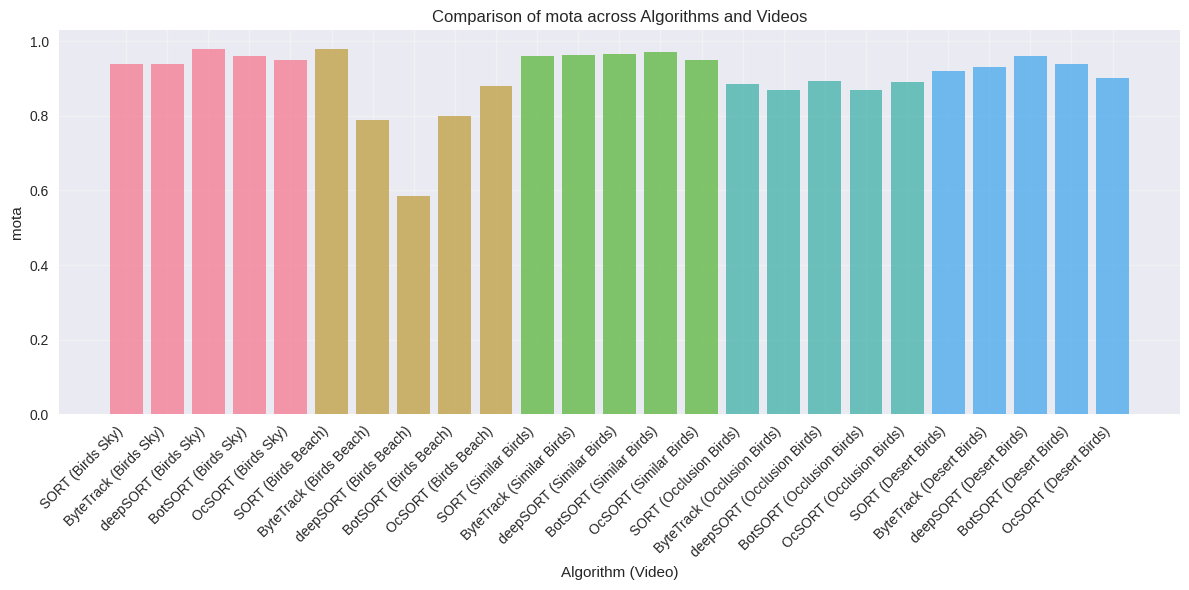

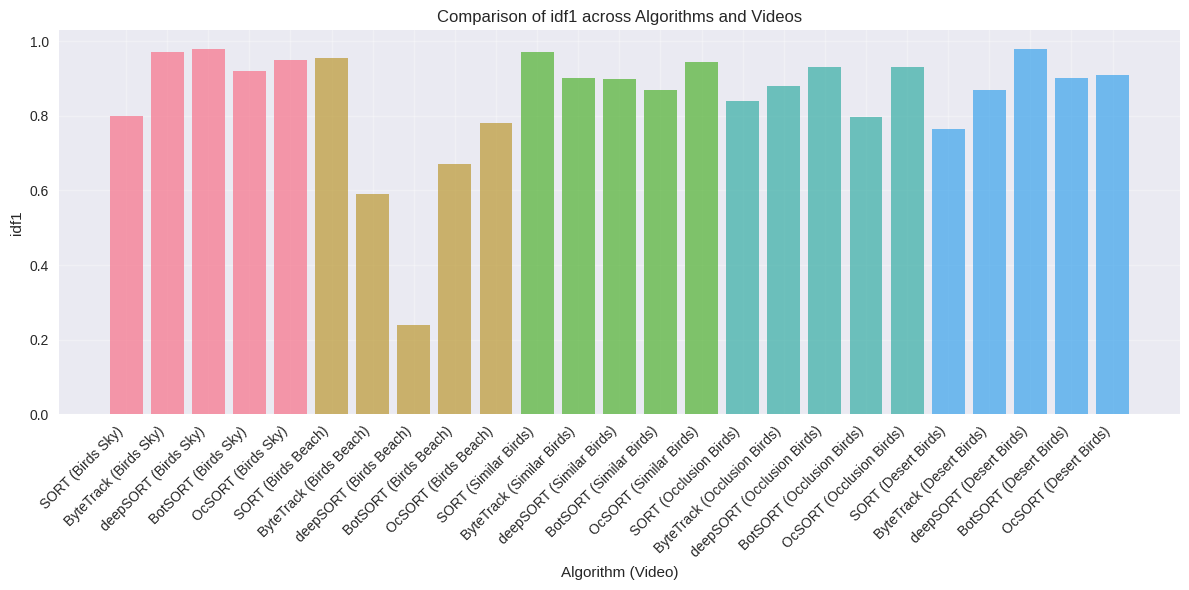

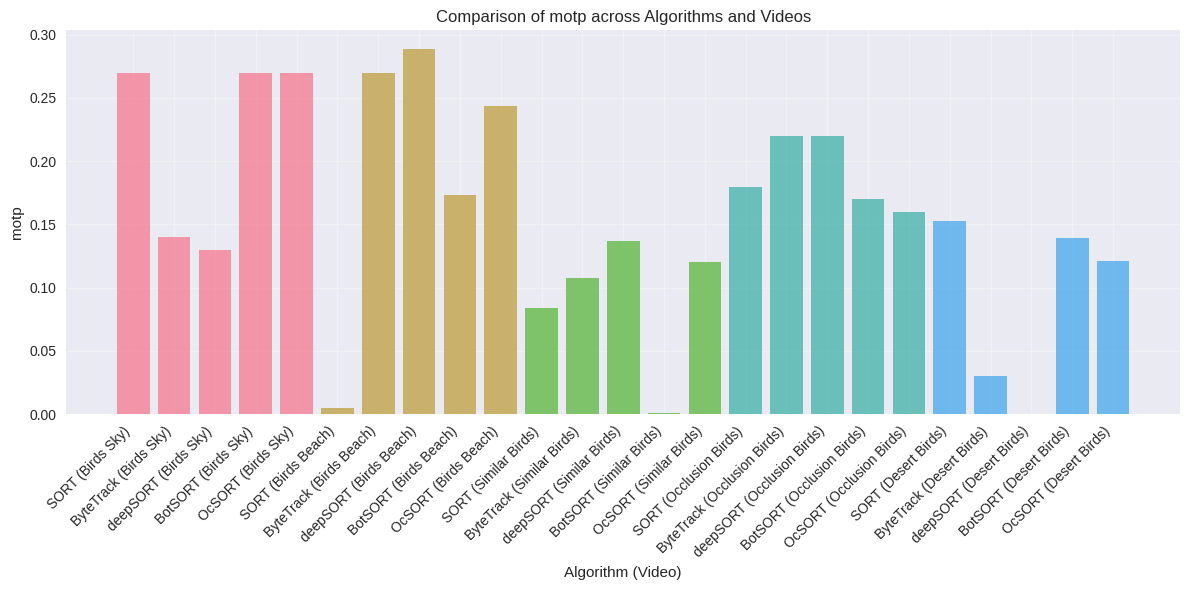

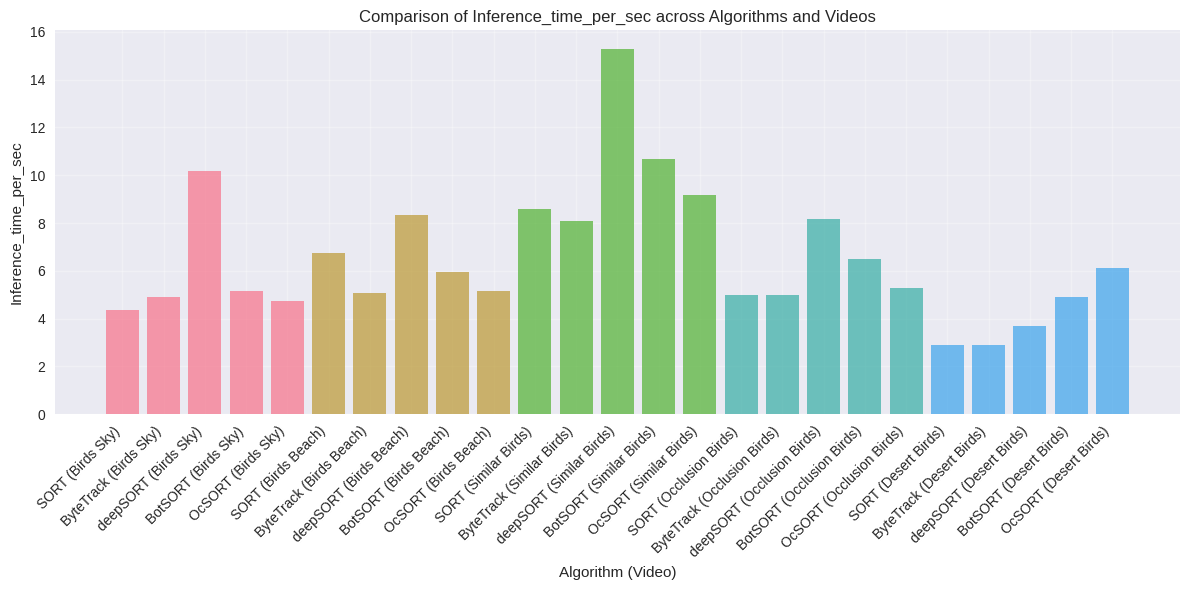

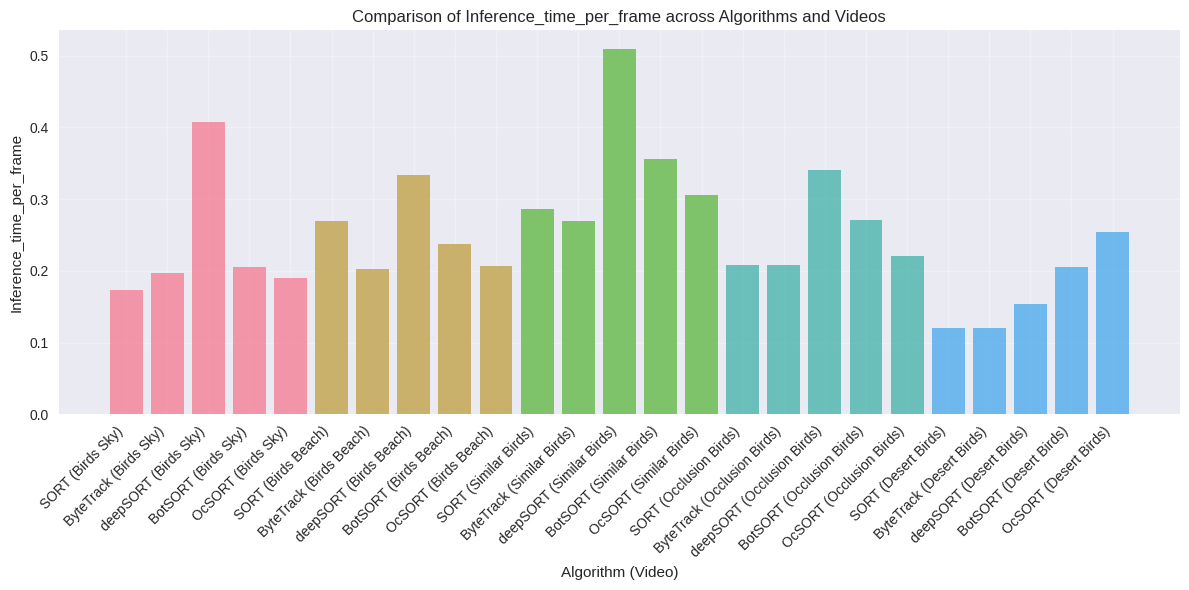

In [5]:
# 📈 One plot per metric: algorithms on x-axis, bars per video
for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))
    for video in df['Video'].unique():
        subset = df[df['Video'] == video]
        values = subset[['Algorithm', metric]].dropna()
        plt.bar(
            values['Algorithm'] + f" ({video})",
            values[metric],
            label=video,
            alpha=0.7
        )

    plt.title(f'Comparison of {metric} across Algorithms and Videos')
    plt.xlabel('Algorithm (Video)')
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
